In [2]:
!pip install tqdm

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from parameters import *

## Ramp Slope Analysis 

### GOE

In [6]:
dataList = []
dataList.append(np.loadtxt(f"SFF/goe_sff_data,j={j},M={M},N={N},ntraj=1000.dat",dtype=complex))

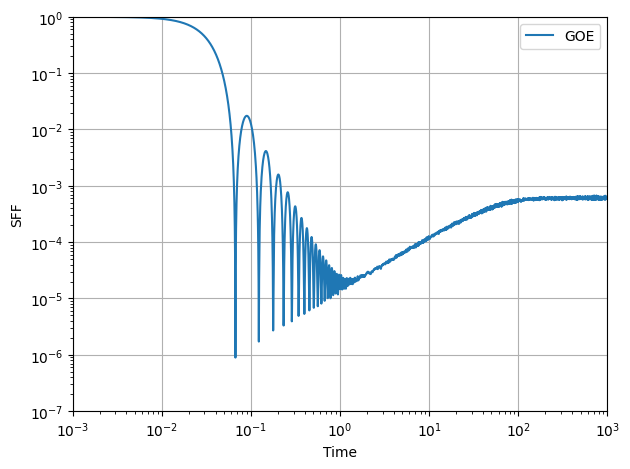

In [19]:
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Time")
plt.ylabel("SFF")
plt.xlim(1e-3,1e3)
plt.ylim(1e-7,1)

# GOE data
data1 = np.loadtxt(f"SFF/goe_sff_data,j={j},M={M},N={N},ntraj=1000.dat",dtype=complex)

# Isolate the ramp
indl = int(2.05e3); indr = int(4e3)
indl = int(2e3); indr = int(3.4e3)
data_ramp_GOE = data1[indl:indr]

# Plot the actual data
data1 = np.column_stack(data1)
plt.plot(data1[0],data1[1],label=f"GOE")

# Plot the ramp
data_ramp_GOE = np.column_stack(data_ramp_GOE)
# plt.plot(data_ramp_GOE[0], data_ramp_GOE[1])

# Plot the fit
# Fit the ramp
m,b = np.polyfit(np.log10(data_ramp_GOE[0]),np.log10(data_ramp_GOE[1]),1)
# print(f"g={round(g_arr[g_ind],2)}, m={round(np.real(m),2)},t={round(np.real(data1[0][indl]),2)}")
# plt.plot(data1[0], 10**b*data1[0]**m,'--',label= f"slope = {round(np.real(m),2)}")
#plt.plot(data[0], 10**b*data[0]**m,'--',label=f"g={np.round(g_arr[g_ind])}, m={round(np.real(m),2)}")

plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('GOE SFF')

## Dicke

In [24]:
g_arr = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# g_arr = [0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

In [25]:
dataList = []
for g in g_arr:
    data = np.loadtxt(f"SFF/SFFvsTime,j={j},M={M},g={g},beta={beta}.dat", dtype=complex)
    # Rolling average data points
    data_rl = []
    # Window size for rolling average
    win = 100
    for data_ind in tqdm(range(0,len(data),1)):
        win_start = int(data_ind)
        win_end = int(data_ind+win)
        data_rl_val = np.average(data[win_start:win_end], axis=0)
        data_rl.append(data_rl_val)
    dataList.append(data_rl)

100%|██████████| 5000/5000 [00:00<00:00, 49117.31it/s]


g=0.1, m=1.67,t=1.45
g=0.2, m=1.72,t=1.45
g=0.3, m=1.49,t=1.45
g=0.4, m=1.2,t=1.45
g=0.5, m=1.07,t=1.45
g=0.6, m=0.89,t=1.45
g=0.7, m=0.89,t=1.45
g=0.8, m=0.87,t=1.45
g=0.9, m=0.95,t=1.45
g=1.0, m=0.84,t=1.45


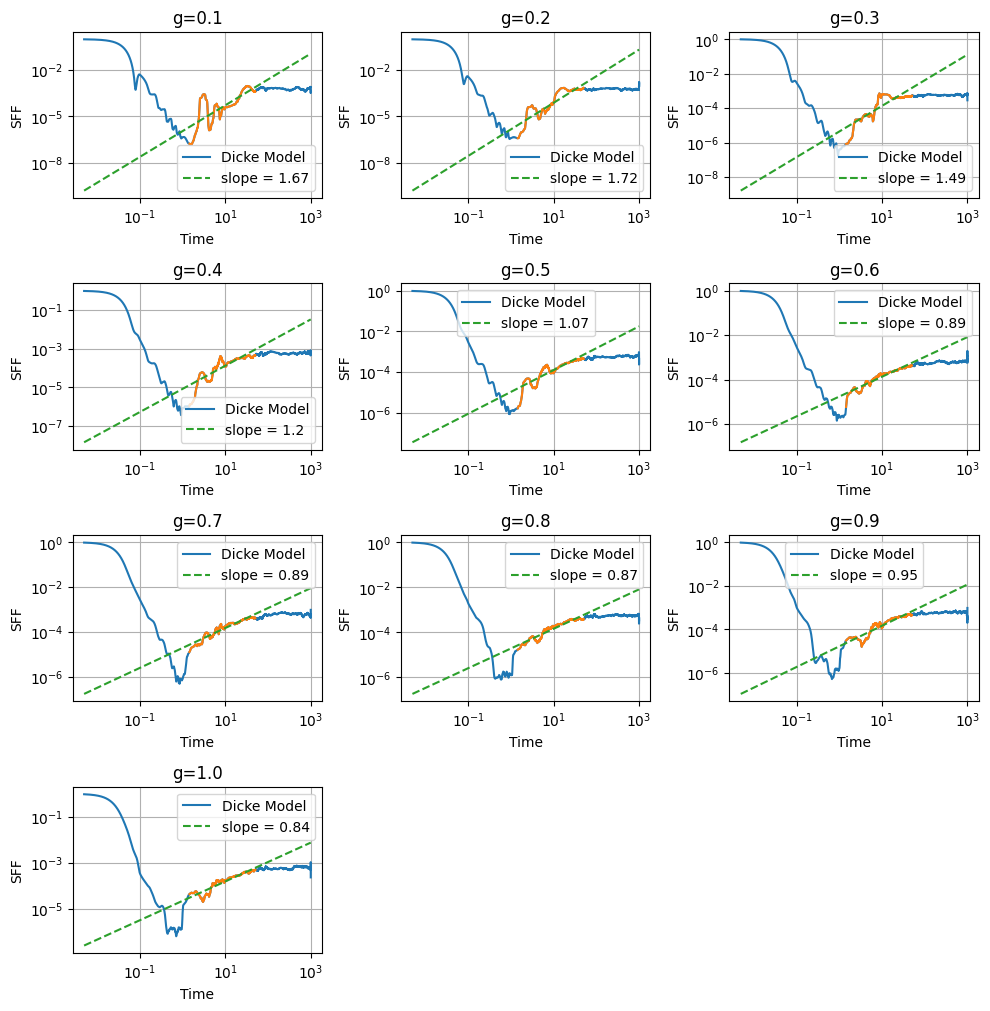

In [26]:
plt.figure(figsize=(10,50))
m_arr = []
for g_ind, data in enumerate(dataList):
    #plt.suptitle(f"Dicke Model SFF (j={j}, M={M})")
    plt.subplot(20,3,g_ind+1)
    plt.title(f"g={round(g_arr[g_ind],2)}")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Time")
    plt.ylabel("SFF")
    # plt.xlim(1e-3,1e3)
    # plt.ylim(1e-7,1)
    
    # Isolate the ramp
    indl = int(2e3); indr = int(3.4e3)
    data_ramp = data[indl:indr]

    # Plot the actual data
    data = np.column_stack(data)
    plt.plot(data[0],data[1],label="Dicke Model")

    # Plot the ramp
    data_ramp = np.column_stack(data_ramp)
    plt.plot(data_ramp[0], data_ramp[1])

    # Plot the fit
    # Fit the ramp
    m,b = np.polyfit(np.log10(data_ramp[0]),np.log10(data_ramp[1]),1)
    print(f"g={round(g_arr[g_ind],2)}, m={round(np.real(m),2)},t={round(np.real(data[0][indl]),2)}")
    plt.plot(data[0], 10**b*data[0]**m,'--',label= f"slope = {round(np.real(m),2)}")
    m_arr.append(m)
    plt.legend()
    plt.tight_layout()
    plt.grid()
plt.savefig('Dicke SFF Slope')
plt.show()

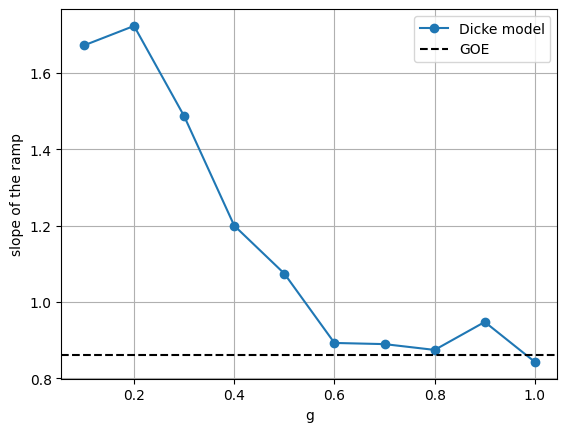

In [27]:
plt.plot(g_arr,m_arr,'-o',label='Dicke model')
plt.xlabel('g')
plt.ylabel('slope of the ramp')
plt.axhline(y=0.86,linestyle='--',color='k',label='GOE')
plt.grid()
plt.legend()
plt.savefig("ramp slope vs g")